<a href="https://colab.research.google.com/github/biswal-prem-5677/Coding-Journey/blob/main/languages/python/libraries/data_analysis_stack/experiment_expense_tracker_analysis_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Expense Tracker: Import Data

In [4]:
import pandas as pd
import kagglehub
import os
import glob

print("Downloading financial transactions dataset from Kaggle...")
# Download the dataset using kagglehub
dataset_path = kagglehub.dataset_download("artemkabseu/financial-transactions-dataset-expenses-and-income")

print(f"Dataset downloaded to: {dataset_path}")

# List files in the downloaded directory to find the CSV file
# This dataset usually contains a 'transactions.csv' directly in its folder, or in a subfolder.
# Let's find all CSV files in the downloaded directory and its subdirectories.

csv_files = glob.glob(os.path.join(dataset_path, '**/*.csv'), recursive=True)

if not csv_files:
    print(f"Error: No CSV files found in the dataset directory: {dataset_path}")
elif len(csv_files) == 1:
    csv_file_path = csv_files[0]
    print(f"Found CSV file: {csv_file_path}")
    try:
        df = pd.read_csv(csv_file_path)
        print("Financial transactions data loaded successfully!")
        display(df.head())
    except Exception as e:
        print(f"An error occurred while loading the data: {e}")
else:
    print("Multiple CSV files found. Please specify which one to load:")
    for i, f in enumerate(csv_files):
        print(f"{i+1}. {f}")
    # For now, let's try to load 'transactions.csv' if it exists, otherwise the first one.
    preferred_csv = next((f for f in csv_files if 'transactions.csv' in os.path.basename(f)), csv_files[0])
    print(f"Attempting to load: {preferred_csv}")
    try:
        df = pd.read_csv(preferred_csv)
        print("Financial transactions data loaded successfully!")
        display(df.head())
    except Exception as e:
        print(f"An error occurred while loading the data: {e}")


Using Colab cache for faster access to the 'financial-transactions-dataset-expenses-and-income' dataset.
Dataset downloaded to: /kaggle/input/financial-transactions-dataset-expenses-and-income
Multiple CSV files found. Please specify which one to load:
1. /kaggle/input/financial-transactions-dataset-expenses-and-income/Expenses_clean.csv
2. /kaggle/input/financial-transactions-dataset-expenses-and-income/Income_clean.csv
Attempting to load: /kaggle/input/financial-transactions-dataset-expenses-and-income/Expenses_clean.csv
Financial transactions data loaded successfully!


,date_time,category,account,amount,currency,tags
0,2025-11-30 00:00:00,Health,acct_1,114.0,BYN,tag_1
1,2025-11-29 00:00:00,Food,acct_1,5.0,BYN,tag_1
2,2025-11-27 00:00:00,Public transport,acct_2,1.0,BYN,tag_1
3,2025-11-27 00:00:00,Cafe,acct_1,10.0,BYN,tag_1
4,2025-11-27 00:00:00,Public transport,acct_2,1.0,BYN,tag_1


### Data Exploration and Cleaning

In [18]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 938 entries, 0 to 937
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date_time    938 non-null    datetime64[ns]
 1   category     938 non-null    object        
 2   account      938 non-null    object        
 3   amount       938 non-null    float64       
 4   currency     938 non-null    object        
 5   tags         938 non-null    object        
 6   year         938 non-null    int32         
 7   month        938 non-null    int32         
 8   day          938 non-null    int32         
 9   day_of_week  938 non-null    int32         
 10  anomaly      938 non-null    int64         
dtypes: datetime64[ns](1), float64(1), int32(4), int64(1), object(4)
memory usage: 66.1+ KB


None

In [6]:
# Check for missing values
display(df.isnull().sum())

,0
date_time,0
category,0
account,0
amount,0
currency,0
tags,0


In [7]:
# Display descriptive statistics for numerical columns
display(df.describe())

,amount
count,938.000000
mean,15.842217
std,78.291145
min,0.000000
25%,1.000000
50%,2.000000
75%,10.000000
max,1172.000000


In [8]:
# Convert 'date_time' to datetime objects
df['date_time'] = pd.to_datetime(df['date_time'])

# Extract year, month, day, and day of week for potential analysis
df['year'] = df['date_time'].dt.year
df['month'] = df['date_time'].dt.month
df['day'] = df['date_time'].dt.day
df['day_of_week'] = df['date_time'].dt.dayofweek # Monday=0, Sunday=6

display(df.head())

,date_time,category,account,amount,currency,tags,year,month,day,day_of_week
0,2025-11-30,Health,acct_1,114.0,BYN,tag_1,2025,11,30,6
1,2025-11-29,Food,acct_1,5.0,BYN,tag_1,2025,11,29,5
2,2025-11-27,Public transport,acct_2,1.0,BYN,tag_1,2025,11,27,3
3,2025-11-27,Cafe,acct_1,10.0,BYN,tag_1,2025,11,27,3
4,2025-11-27,Public transport,acct_2,1.0,BYN,tag_1,2025,11,27,3


### Analyze Spending by Category

Total Spending by Category:


,amount
category,
Loan given,2809.0
Other,2699.0
Food,1538.0
Cafe,1424.0
Gifts,1277.0
Bought for myself,1273.0
Leisure,945.0
Health,804.0
Taxi,770.0


/tmp/ipykernel_735/7702594.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_spending.index, y=category_spending.values, palette='viridis')


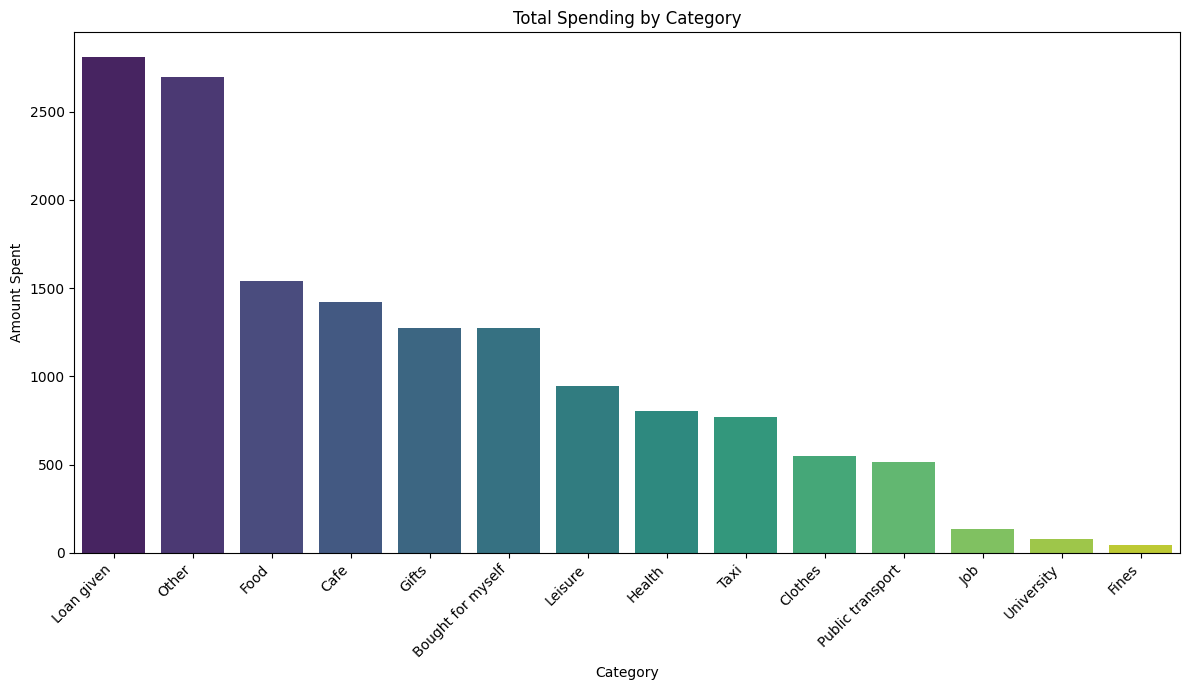

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate total spending by category
category_spending = df.groupby('category')['amount'].sum().sort_values(ascending=False)

print("Total Spending by Category:")
display(category_spending)

# Visualize spending by category
plt.figure(figsize=(12, 7))
sns.barplot(x=category_spending.index, y=category_spending.values, palette='viridis')
plt.title('Total Spending by Category')
plt.xlabel('Category')
plt.ylabel('Amount Spent')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Advanced Feature Engineering

#### Velocity Features: Number of Transactions per Day

Transactions per day:


,date_time,transactions_count
0,2025-01-07,1
1,2025-01-08,1
2,2025-01-09,1
3,2025-01-10,2
4,2025-01-11,1


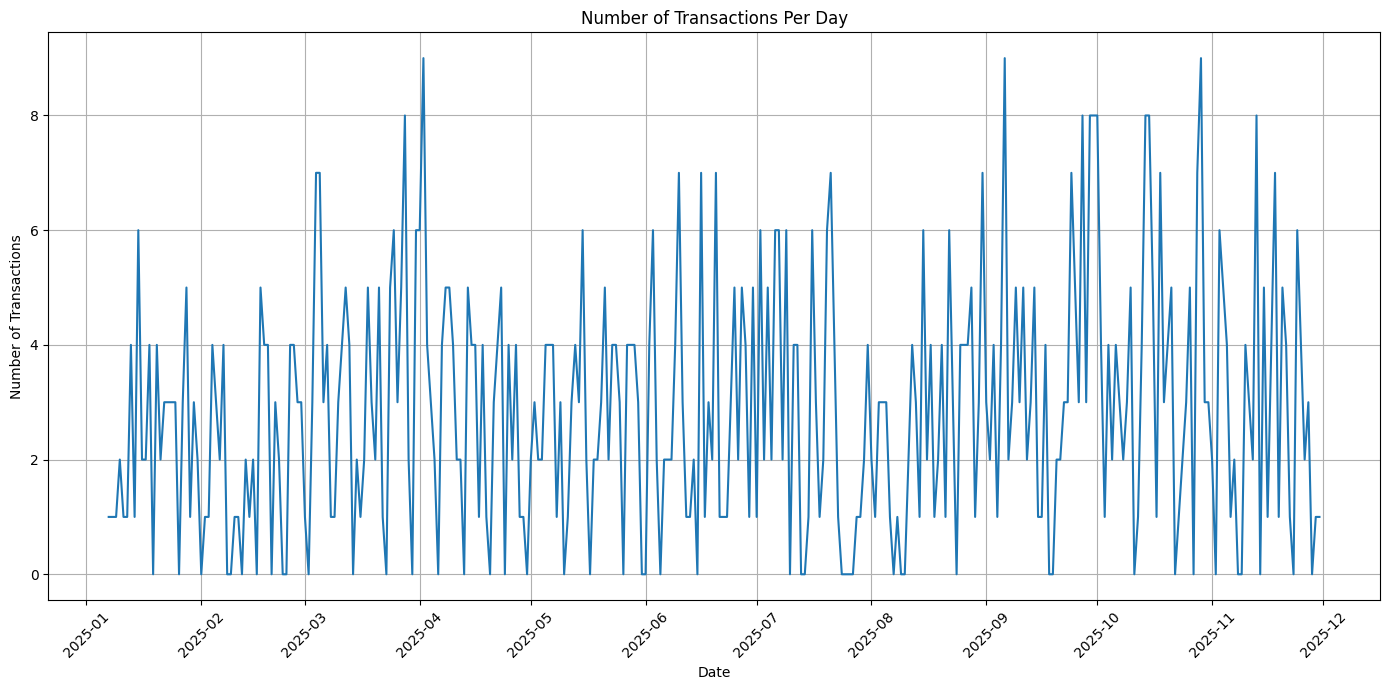

In [10]:
# Calculate the number of transactions per day
# First, ensure 'date_time' is a datetime object and set it as index for resampling.
if not pd.api.types.is_datetime64_any_dtype(df['date_time']):
    df['date_time'] = pd.to_datetime(df['date_time'])

transactions_per_day = df.set_index('date_time').resample('D').size().reset_index(name='transactions_count')

print("Transactions per day:")
display(transactions_per_day.head())

# Visualize transactions per day
plt.figure(figsize=(14, 7))
sns.lineplot(x='date_time', y='transactions_count', data=transactions_per_day)
plt.title('Number of Transactions Per Day')
plt.xlabel('Date')
plt.ylabel('Number of Transactions')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Financial Metrics: Rolling Savings Rate

In [11]:
# To calculate the savings rate, we first need to load the income data.
# The 'Income_clean.csv' file was identified earlier in the dataset.

income_csv_path = None
for f in csv_files:
    if 'Income_clean.csv' in os.path.basename(f):
        income_csv_path = f
        break

if income_csv_path:
    print(f"Loading income data from: {income_csv_path}")
    df_income = pd.read_csv(income_csv_path)
    print("Income data loaded successfully!")
    display(df_income.head())

    # Convert 'date_time' to datetime objects for income data as well
    df_income['date_time'] = pd.to_datetime(df_income['date_time'])
    df_income['year'] = df_income['date_time'].dt.year
    df_income['month'] = df_income['date_time'].dt.month
else:
    print("Error: Income_clean.csv not found in the downloaded dataset. Cannot calculate savings rate.")

Loading income data from: /kaggle/input/financial-transactions-dataset-expenses-and-income/Income_clean.csv
Income data loaded successfully!


,date_time,category,account,amount,currency,tags
0,2025-11-29 00:00:00,Job,acct_1,49.0,BYN,tag_1
1,2025-11-29 00:00:00,Job,acct_1,18.0,BYN,tag_2
2,2025-11-29 00:00:00,Job,acct_1,32.0,BYN,tag_3
3,2025-11-29 00:00:00,Job,acct_1,109.0,BYN,tag_4
4,2025-11-28 00:00:00,Second work,acct_1,132.0,BYN,2th_work


Monthly Financials and Rolling Savings Rate:


/tmp/ipykernel_735/1166568420.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  monthly_financials['savings_rate'].replace([-float('inf'), float('inf')], 0, inplace=True) # Replace inf with 0


,year,month,total_income,total_expenses,date,savings,savings_rate,rolling_savings_rate_3m
6,2025,7,1967.0,821.0,2025-07-01,1146.0,58.261312,65.037703
7,2025,8,2359.0,835.0,2025-08-01,1524.0,64.603646,63.885685
8,2025,9,5730.0,2928.0,2025-09-01,2802.0,48.900524,57.255160
9,2025,10,2993.0,1960.0,2025-10-01,1033.0,34.513866,49.339345
10,2025,11,1317.0,904.0,2025-11-01,413.0,31.359150,38.257846


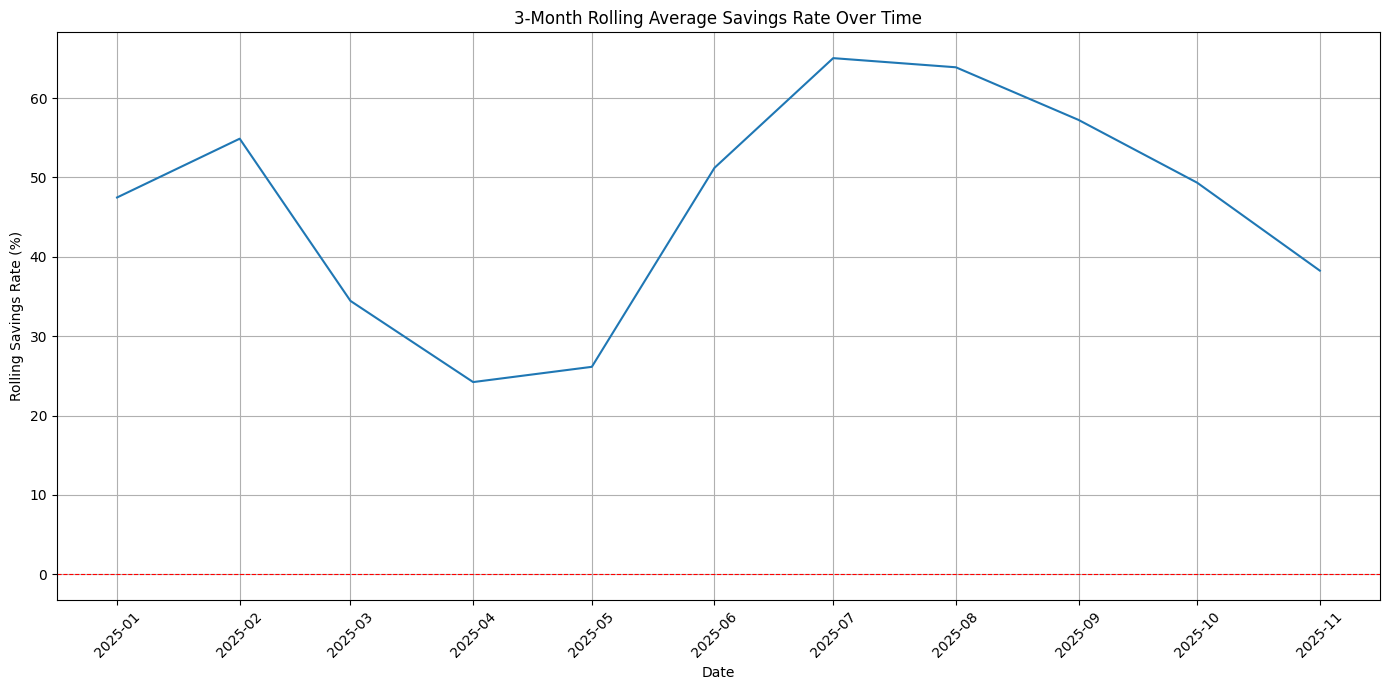

In [12]:
if 'df_income' in locals() and not df_income.empty:
    # Aggregate monthly expenses
    monthly_expenses = df.groupby(['year', 'month'])['amount'].sum().reset_index()
    monthly_expenses.rename(columns={'amount': 'total_expenses'}, inplace=True)

    # Aggregate monthly income
    monthly_income = df_income.groupby(['year', 'month'])['amount'].sum().reset_index()
    monthly_income.rename(columns={'amount': 'total_income'}, inplace=True)

    # Merge monthly income and expenses
    monthly_financials = pd.merge(monthly_income, monthly_expenses, on=['year', 'month'], how='outer').fillna(0)

    # Sort by date for proper rolling calculation
    monthly_financials['date'] = pd.to_datetime(monthly_financials['year'].astype(str) + '-' + monthly_financials['month'].astype(str) + '-01')
    monthly_financials.sort_values('date', inplace=True)

    # Calculate monthly savings
    monthly_financials['savings'] = monthly_financials['total_income'] - monthly_financials['total_expenses']

    # Calculate Savings Rate (handle division by zero if income is 0)
    monthly_financials['savings_rate'] = (monthly_financials['savings'] / monthly_financials['total_income']) * 100
    monthly_financials['savings_rate'].replace([-float('inf'), float('inf')], 0, inplace=True) # Replace inf with 0
    monthly_financials['savings_rate'] = monthly_financials['savings_rate'].fillna(0) # Fill NaN where total_income was 0

    # Calculate a 3-month rolling average for the savings rate
    monthly_financials['rolling_savings_rate_3m'] = monthly_financials['savings_rate'].rolling(window=3, min_periods=1).mean()

    print("Monthly Financials and Rolling Savings Rate:")
    display(monthly_financials.tail())

    # Visualize the rolling savings rate
    plt.figure(figsize=(14, 7))
    sns.lineplot(x='date', y='rolling_savings_rate_3m', data=monthly_financials)
    plt.axhline(0, color='red', linestyle='--', linewidth=0.8) # Add a line at 0 for reference
    plt.title('3-Month Rolling Average Savings Rate Over Time')
    plt.xlabel('Date')
    plt.ylabel('Rolling Savings Rate (%)')
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Income data not available or empty, skipping savings rate calculation.")

#### Nested Plotly Subplots: Interactive Visualizations

In [15]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Ensure df_filtered exists and is not empty
if 'df_filtered' in locals() and not df_filtered.empty:

    # --- 1. Income vs. Expense Area Chart (Cumulative Cash Flow) ---
    # Re-aggregate monthly financials using the filtered expense data
    monthly_expenses_filtered = df_filtered.groupby(['year', 'month'])['amount'].sum().reset_index()
    monthly_expenses_filtered.rename(columns={'amount': 'total_expenses'}, inplace=True)

    # Use the previously loaded df_income, but filter by date if needed
    # For simplicity, we'll use the full df_income for now, assuming income dates align or are broader
    monthly_income_full = df_income.groupby(['year', 'month'])['amount'].sum().reset_index()
    monthly_income_full.rename(columns={'amount': 'total_income'}, inplace=True)

    monthly_financials_filtered = pd.merge(monthly_income_full, monthly_expenses_filtered, on=['year', 'month'], how='outer').fillna(0)
    monthly_financials_filtered['date'] = pd.to_datetime(monthly_financials_filtered['year'].astype(str) + '-' + monthly_financials_filtered['month'].astype(str) + '-01')
    monthly_financials_filtered.sort_values('date', inplace=True)
    monthly_financials_filtered['cumulative_income'] = monthly_financials_filtered['total_income'].cumsum()
    monthly_financials_filtered['cumulative_expenses'] = monthly_financials_filtered['total_expenses'].cumsum()
    monthly_financials_filtered['cumulative_cash_flow'] = monthly_financials_filtered['cumulative_income'] - monthly_financials_filtered['cumulative_expenses']


    # --- 2. Interactive Donut Chart for Spending Categories ---
    category_spending_filtered = df_filtered.groupby('category')['amount'].sum().reset_index()
    category_spending_filtered = category_spending_filtered.sort_values(by='amount', ascending=False)

    # --- 3. Breakdown of Payment Methods (using 'account' as proxy for payment method) ---
    # We need to find a way to map 'account' to 'payment method' if it's not direct
    # For now, let's assume 'account' column represents payment methods.
    payment_method_breakdown = df_filtered.groupby('account')['amount'].sum().reset_index()
    payment_method_breakdown = payment_method_breakdown.sort_values(by='amount', ascending=False)

    # Create subplots
    fig = make_subplots(rows=2, cols=2,
                        specs=[[{'type':'xy', "colspan": 2}, None],
                               [{'type':'domain'}, {'type':'xy'}]], # Corrected: Set type for pie chart
                        subplot_titles=('Cumulative Cash Flow: Income vs. Expenses',
                                        'Spending Categories Breakdown',
                                        'Payment Method Breakdown'))

    # Add Cumulative Cash Flow Chart (Row 1, Col 1-2)
    fig.add_trace(go.Scatter(x=monthly_financials_filtered['date'], y=monthly_financials_filtered['cumulative_income'],
                             mode='lines', stackgroup='one', name='Cumulative Income', fillcolor='rgba(0,100,80,0.2)'),
                  row=1, col=1)
    fig.add_trace(go.Scatter(x=monthly_financials_filtered['date'], y=monthly_financials_filtered['cumulative_expenses'],
                             mode='lines', stackgroup='one', name='Cumulative Expenses', fillcolor='rgba(255,0,0,0.2)'),
                  row=1, col=1)
    fig.update_yaxes(title_text='Cumulative Amount', row=1, col=1)
    fig.update_xaxes(title_text='Date', row=1, col=1)

    # Add Spending Categories Donut Chart (Row 2, Col 1)
    fig.add_trace(go.Pie(labels=category_spending_filtered['category'], values=category_spending_filtered['amount'],
                         hole=0.4, name='Categories', scalegroup='one'),
                  row=2, col=1)

    # Add Payment Method Breakdown (Row 2, Col 2)
    fig.add_trace(go.Bar(x=payment_method_breakdown['account'], y=payment_method_breakdown['amount'], name='Payment Methods'),
                  row=2, col=2)
    fig.update_yaxes(title_text='Amount Spent', row=2, col=2)
    fig.update_xaxes(title_text='Account (Payment Method)', row=2, col=2)

    fig.update_layout(title_text='Interactive Financial Dashboard', height=900, showlegend=True)
    fig.show()
else:
    print("Filtered DataFrame (df_filtered) is not available or is empty. Please run the previous cell with date filters.")

### Machine Learning Enhancements

#### Anomaly Detection: IsolationForest

Detected Anomalous Transactions:


,date_time,category,account,amount,currency,tags,year,month,day,day_of_week,anomaly
0,2025-11-30,Health,acct_1,114.0,BYN,tag_1,2025,11,30,6,-1
28,2025-11-18,Gifts,acct_1,79.0,BYN,tag_1,2025,11,18,1,-1
65,2025-11-05,Clothes,acct_1,299.0,BYN,tag_1,2025,11,5,2,-1
100,2025-10-28,Bought for myself,acct_1,64.0,BYN,tag_1,2025,10,28,1,-1
105,2025-10-26,Health,acct_1,128.0,BYN,tag_1,2025,10,26,6,-1


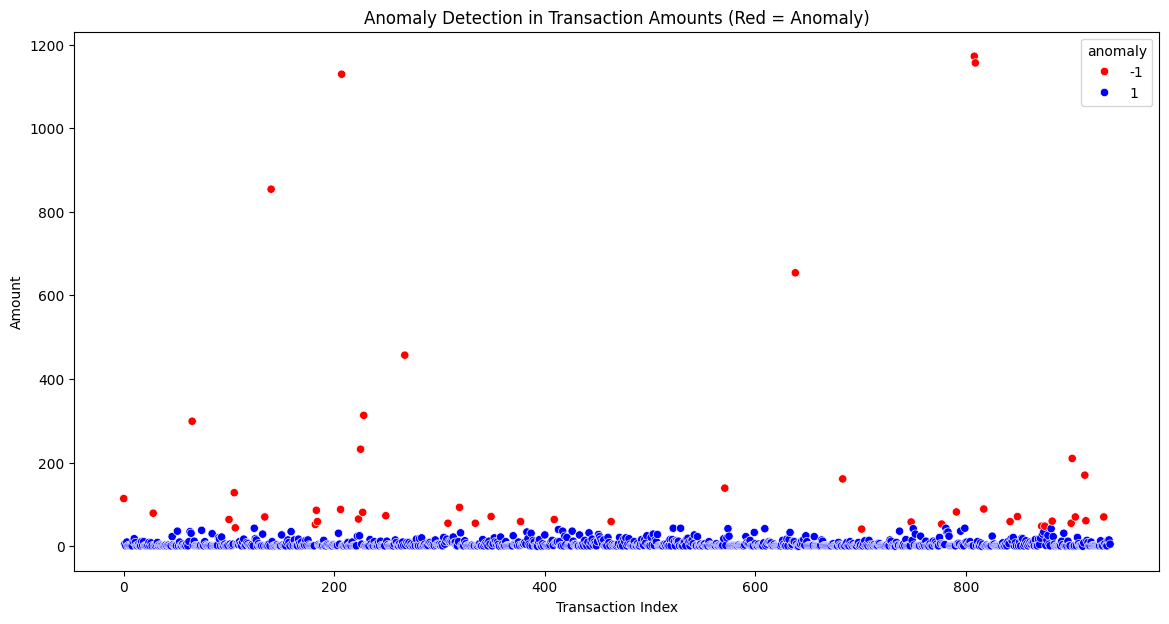

In [16]:
from sklearn.ensemble import IsolationForest
import numpy as np

# Prepare data for anomaly detection
# We'll use 'amount' as the primary feature for anomaly detection
# Consider other numerical features or aggregated features if available and relevant

X = df[['amount']]

# Train Isolation Forest model
# contamination: The proportion of outliers in the data set. Adjusted based on potential outlier percentage.
model = IsolationForest(contamination=0.05, random_state=42) # Assuming 5% of data might be anomalous
model.fit(X)

# Predict anomalies (-1 for outliers, 1 for inliers)
df['anomaly'] = model.predict(X)

# Filter for anomalies
anomalies = df[df['anomaly'] == -1]

print("Detected Anomalous Transactions:")
display(anomalies.head())

# Visualize anomalies
plt.figure(figsize=(14, 7))
sns.scatterplot(x=df.index, y='amount', hue='anomaly', data=df, palette={1: 'blue', -1: 'red'})
plt.title('Anomaly Detection in Transaction Amounts (Red = Anomaly)')
plt.xlabel('Transaction Index')
plt.ylabel('Amount')
plt.show()

#### Expense Forecasting: Time-Series Model

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.


Expense Forecast for the next 3 months:


,ds,yhat,yhat_lower,yhat_upper
413,2026-02-24,53.300212,-158.047117,258.429665
414,2026-02-25,56.243542,-149.925493,250.587919
415,2026-02-26,53.478083,-155.667017,258.590833
416,2026-02-27,52.845419,-146.788820,263.515757
417,2026-02-28,52.718831,-138.395415,257.923034


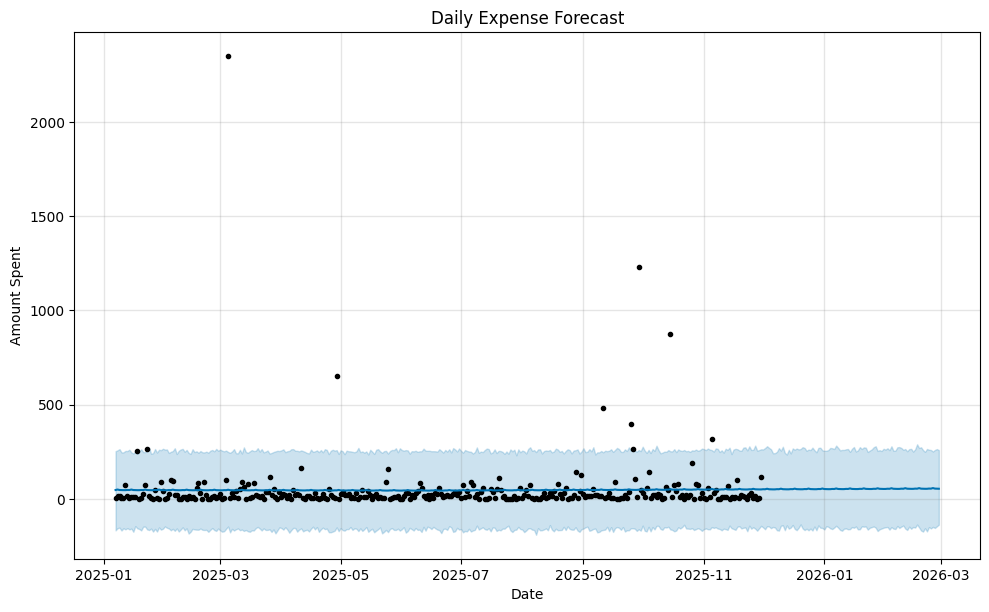

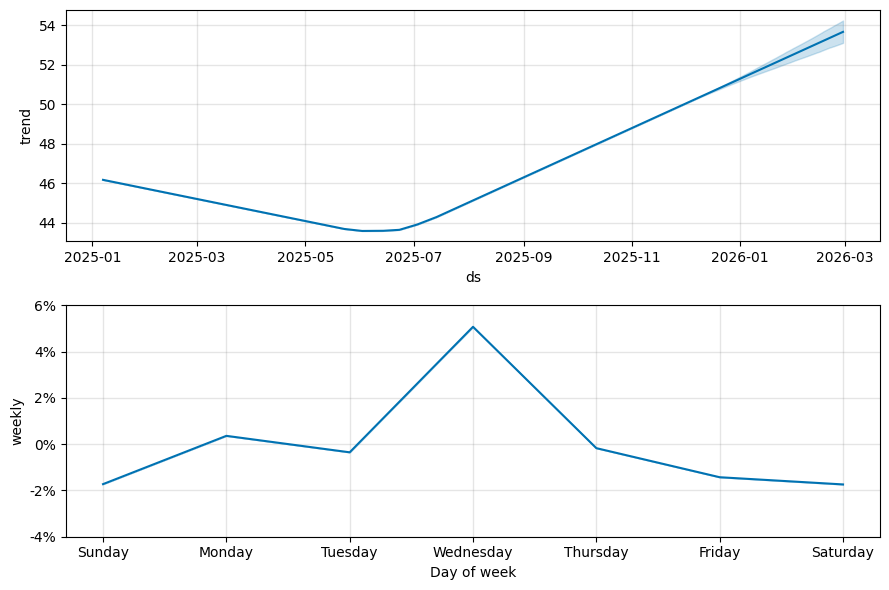

In [17]:
from prophet import Prophet

# Prepare data for forecasting
# We need a DataFrame with 'ds' (datestamp) and 'y' (target variable, e.g., total monthly expenses)

# Aggregate daily expenses first
daily_expenses = df.set_index('date_time')['amount'].resample('D').sum().reset_index()
daily_expenses.rename(columns={'date_time': 'ds', 'amount': 'y'}, inplace=True)

# Initialize and fit the Prophet model
model = Prophet(
    seasonality_mode='multiplicative',
    weekly_seasonality=True,  # Daily data might show weekly patterns
    daily_seasonality=False   # No daily seasonality if aggregated daily
)

# Add custom seasonality for monthly patterns if desired
# model.add_seasonality(name='monthly', period=30.5, fourier_order=5)

model.fit(daily_expenses)

# Create a DataFrame for future dates to forecast
future = model.make_future_dataframe(periods=90) # Forecast for the next 90 days (approx 3 months)

# Make predictions
forecast = model.predict(future)

print("Expense Forecast for the next 3 months:")
display(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

# Plot the forecast
fig = model.plot(forecast)
plt.title('Daily Expense Forecast')
plt.xlabel('Date')
plt.ylabel('Amount Spent')
plt.show()

# Plot the forecast components
fig2 = model.plot_components(forecast)
plt.show()

### Interactive Dashboard Architecture

#### Colab Native Forms: Dynamic Date Filtering

In [13]:
import ipywidgets as widgets
from IPython.display import display, HTML
import datetime

# Get min and max dates from the DataFrame for default filter ranges
min_date = df['date_time'].min().date()
max_date = df['date_time'].max().date()

#@param {type: "date"}
start_date = min_date #@param
end_date = max_date #@param

print(f"Filtering data from {start_date} to {end_date}.")

# Convert start_date and end_date from date objects to datetime objects for comparison
filtered_start_dt = pd.to_datetime(start_date)
filtered_end_dt = pd.to_datetime(end_date)

# Apply the date filter to the main DataFrame
df_filtered = df[(df['date_time'] >= filtered_start_dt) & (df['date_time'] <= filtered_end_dt)]

print(f"Original DataFrame shape: {df.shape}")
print(f"Filtered DataFrame shape: {df_filtered.shape}")

print("Filtered Data Head:")
display(df_filtered.head())

Filtering data from 2025-01-07 to 2025-11-30.
Original DataFrame shape: (938, 10)
Filtered DataFrame shape: (938, 10)
Filtered Data Head:


,date_time,category,account,amount,currency,tags,year,month,day,day_of_week
0,2025-11-30,Health,acct_1,114.0,BYN,tag_1,2025,11,30,6
1,2025-11-29,Food,acct_1,5.0,BYN,tag_1,2025,11,29,5
2,2025-11-27,Public transport,acct_2,1.0,BYN,tag_1,2025,11,27,3
3,2025-11-27,Cafe,acct_1,10.0,BYN,tag_1,2025,11,27,3
4,2025-11-27,Public transport,acct_2,1.0,BYN,tag_1,2025,11,27,3
